## NUMPY 

What is NumPy?
NumPy, short for Numerical Python, is one of the most important foundational packages for numerical computing in Python. It is specifically designed for efficiency on large arrays of data. NumPy stores data in contiguous blocks of memory and uses C-based algorithms to perform complex computations on entire arrays—completely bypassing the need for slow Python for loops

1. The ndarray Object   
The core feature of NumPy is its N-dimensional array object, or ndarray. It is a fast, flexible container for large datasets that allows you to perform batch mathematical operations using the same syntax you would use for single scalar values. 
 Every array has two important attributes:  
 shape: A tuple indicating the size of each dimension.
 dtype: An object describing the data type of the array (e.g., float64, int32).

2. Creating Arrays
The easiest way to create an array is to use the np.array function, which accepts any sequence-like object (like a list) and converts it into a NumPy array.  

# Lecture 1: NumPy Basics, Creating Arrays, Arithmetic, and Data Types

In [73]:
import numpy as np 

# Creating a 1-dimensional array from a list
data1 = [6,2.7,5,8,8.8]
arr1 = np.array(data1)

# Creating a 2-dimensional array from a list of lists
data2 = [[2.7 ,3,9] , 
         [6,7,8]
         ]
arr2 = np.array(data2)
type(arr2)

# Creating a 2-dimensional  unequal element array  from a list of lists
arr3 = np.array([[3,4] , [4,5,6] ], dtype = object)
type(arr3)
print(arr3)
print(arr2)



[list([3, 4]) list([4, 5, 6])]
[[2.7 3.  9. ]
 [6.  7.  8. ]]


NumPy also provides built-in functions to generate arrays from scratch:  

In [74]:
np.zeros(10)   # Creates an array of 10 zeros

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [75]:
np.ones((3,6))   # Creates a 3x6 multidimensional array of 1s
np.ones((2,3,4))

array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]])

In [76]:
np.arange(5,15)  #  Works just like Python's built-in range() function, but returns an array instead of a list.

array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

3. Array Arithmetic (Vectorization)
One of the most powerful features of arrays is that they enable you to perform operations on entire datasets without writing loops. NumPy users call this vectorization.  
Any arithmetic operations between equal-size arrays apply the operation element-by-element:  

In [77]:
arr  = np.array([[2,3,4] , 
                 [5,6,7]])

# Multiplication multiplies corresponding elements
print(arr*arr)

# Arithmetic with scalars propagates the value to each element
arr* 10 

[[ 4  9 16]
 [25 36 49]]


array([[20, 30, 40],
       [50, 60, 70]])

4. Data Types and Casting
You can explicitly convert (or cast) an array from one data type to another using the astype method.

In [78]:
arr = np.array([1, 2, 3, 4, 5]) # This is an integer array
float_arr = arr.astype(np.float64) # Now it is a float array

 ## Lecture 2: Indexing and Slicing (Learning how to select specific data, including basic slicing, boolean indexing, and "fancy" indexing).

Now that you know how to create arrays, you need to know how to extract specific data from them. NumPy offers several ways to index data, and some of them are quite different from standard Python lists.

1. Basic Indexing and Slicing (and "Views")

One-dimensional NumPy arrays act similarly to standard Python lists. You can select single elements or slice them using the start:stop:step syntax.

In [79]:
arr = np.arange(10)
print(arr)       # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
print(arr[5])    # Output: 5
print(arr[5:9])  # Output: array([5, 6, 7, 8])

[0 1 2 3 4 5 6 7 8 9]
5
[5 6 7 8]


Crucial Concept: Slices are VIEWS

Unlike Python lists, NumPy array slices are views of the original array, not copies. This means if you modify a slice, you modify the original array! This is done to save memory when working with massive datasets.

In [80]:
arr[5:8] = 12   # This "broadcasts" 12 to all three positions
print(arr)
# Output: [ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9]

""" If you ever actually want a copy, you must explicitly use """
copied_arr = arr[5:8].copy()
print(copied_arr)   # Output: [12 12 12]



[ 0  1  2  3  4 12 12 12  8  9]
[12 12 12]


For 2D arrays (matrices), elements at each index are no longer scalars, but 1D arrays. You can access individual elements by passing a comma-separated list of indices:

In [81]:
arr2d = np.array([[1,2,3] , 
                  [4,5,6] , 
                  [7,8,9]])
# Access row 0, column 2
print(arr2d[0,2])    # Output: 3
print(arr2d[1,1])    # Output: 5
print(arr2d[0,0])    # Output: 1

"""Access rows"""
print(arr2d[0])      # Output: [1 2 3]
print(arr2d[:, 1])   # Access an entire column = [2 5 8]
print(arr2d[:2])     # Access the first two rows
 


3
5
1
[1 2 3]
[2 5 8]
[[1 2 3]
 [4 5 6]]


In [82]:
# Access the first two columns
print(arr2d[:,:2])

[[1 2]
 [4 5]
 [7 8]]


In [83]:
# Access a subarray
print(arr2d[1:,1:])

[[5 6]
 [8 9]]


In [84]:
# Access the last row
print(arr2d[2])
print(arr2d[-1])

[7 8 9]
[7 8 9]


## 2. Boolean Indexing

This is an incredibly powerful feature for data cleaning. You can use arrays of boolean values (True / False) to filter your data.

Imagine you have an array of names and a matrix of data corresponding to those names:

In [ ]:
names = np.array(["Yashraj" , "Shahid" , "Yashraj" , "Yash" , "Pramveer"])
data = np.random.randn(5,5)   # A 5x4 matrix of random numbers
print(data)
name_yashraj = (names == "Yashraj")
print(name_yashraj)
data[:,name_yashraj]  # Use that boolean array to select the corresponding rows in 'data

[[-1.76636437 -0.10398828  0.79929282  0.02859447  0.47484878]
 [ 0.54636882  0.45848887  0.68906963  0.24510856 -1.23205916]
 [-0.18473529  2.1653278   1.11614173  2.25340733  0.32216492]
 [-0.48752103 -0.2737774  -0.32058123  0.15437314 -0.37324407]
 [-0.22620406 -0.11103276 -1.21084999  1.20856372 -0.47521987]]
[ True False  True False False]


array([[-1.76636437,  0.79929282],
       [ 0.54636882,  0.68906963],
       [-0.18473529,  1.11614173],
       [-0.48752103, -0.32058123],
       [-0.22620406, -1.21084999]])

### Boolean Indexing (Examples):

In [94]:
arr = np.array([10, 20, 30, 40, 50, 60])
"""Select values greater than 30"""
print(arr>30)
print(arr[arr>30])

[False False False  True  True  True]
[40 50 60]


In [95]:
# Select values less than 40
print(arr[arr<40])

[10 20 30]


### Boolean Indexing with 2D Arrays

In [104]:
arr3d = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

In [105]:
# Get all even numbers
print(arr3d[arr3d % 2 == 0 ])

[10 20 30 40 50 60 70 80 90]


In [107]:
 # Values greater than 20 AND less than 50:
print(arr3d[(arr3d>20) & (arr3d<50)])

[30 40]


 ### Modifying Values with Boolean Indexing

In [109]:
array = np.array([10,20,30,40,50,60])
array[array>30] = 60
print(array)

[10 20 30 60 60 60]


## 3. Fancy Indexing

In [118]:
np.empty((8,4))
for i in range(8):
    arr[i]  = i 

print(arr.astype(int))

# Select rows 4, 3, 0, and 6 in that exact order
arr[[4,3,0,6]]


[[0 0 0 0]
 [1 1 1 1]
 [2 2 2 2]
 [3 3 3 3]
 [4 4 4 4]
 [5 5 5 5]
 [6 6 6 6]
 [7 7 7 7]]


array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

### Examples:
 

In [ ]:
# Basic 1D Fancy Indexing
np_arr = np.array([10,
                   20,
                   30,
                   40,
                   50,
                   60])
print(np_arr.shape)
print(np_arr[[3,3,4,5]])  # you are also controlling the order & can repeatc the elements 

(6,)
[40 40 50 60]


In [127]:
# Fancy Indexing in 2D Arrays:
np_arr2d = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])


In [ ]:
print(np_arr2d[2,1])
print(np_arr2d[[1,2]])   # Select specific rows

80
[[40 50 60]
 [70 80 90]]


In [ ]:
# Selecting specific elements (row-wise pairs)
print(np_arr2d[[0,1,2], [0,1,2]])  # diagonal matrix 

[10 50 80]


In [ ]:
# Important rule
# Fancy indexing returns a copy, not a view.
sub = np_arr2d[[0, 1]]
print(sub)
sub[0] = 100
print(sub)




[[10 20 30]
 [40 50 60]]
[[100 100 100]
 [ 40  50  60]]


 ## Lecture 3: 

Transposing Arrays and Universal Functions (Swapping axes and applying fast, element-wise array functions like square roots or exponentials).

Welcome to Lecture 3! Now that you know how to create and slice arrays, we are going to look at two powerful ways to manipulate and perform calculations on them: Transposing and Universal Functions.

### 1. Transposing Arrays and Swapping Axes

Transposing is a special form of reshaping that swaps the axes of an array. Just like slicing, transposing returns a view on the underlying data without actually copying anything in memory.

The simplest way to transpose a 2D array (a matrix) is using the .T attribute. This is extremely useful in mathematical and statistical modeling, such as calculating an inner matrix product using np.dot.

In [ ]:
# # Create a 3x5 matrix
arr = np.arange(15).reshape(3,5)
print(arr)
# Transpose it to a 5x3 matrix using .T
transposed = arr.T
print(transposed)   # shape (5,3)




[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
[[ 0  5 10]
 [ 1  6 11]
 [ 2  7 12]
 [ 3  8 13]
 [ 4  9 14]]


### Examples :

In [145]:
#  Basic 2D Matrix Transpose :
import numpy as np

a = np.array([[1, 2, 3],
              [4, 5, 6]])

print(a.T)


[[1 4]
 [2 5]
 [3 6]]


In [149]:
# 3D Array Transpose (Axis Swapping):
a = np.arange(24).reshape(2,3,4)
print(a)
print(a.shape)
print(a.T)

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]
(2, 3, 4)
[[[ 0 12]
  [ 4 16]
  [ 8 20]]

 [[ 1 13]
  [ 5 17]
  [ 9 21]]

 [[ 2 14]
  [ 6 18]
  [10 22]]

 [[ 3 15]
  [ 7 19]
  [11 23]]]


In [152]:
 # Custom Axis Rearrangement (np.transpose)
a = np.arange(24).reshape(2,3,4)
b = np.transpose(a , (1,0,2))
print(b)

[[[ 0  1  2  3]
  [12 13 14 15]]

 [[ 4  5  6  7]
  [16 17 18 19]]

 [[ 8  9 10 11]
  [20 21 22 23]]]


| New axis position | Comes from old axis |
| ----------------- | ------------------- |
| axis 0            | axis 1              |
| axis 1            | axis 0              |
| axis 2            | axis 2              |

old : (2, 3, 4)
becomes : (3, 2, 4)


 ### Binary ufuncs (take two arrays and return one)

These functions take two arrays and perform an element-wise operation between them, returning a single new array.

In [ ]:
x = np.array([1,5,3])
y = np.array([2,2,8])
# Element-wise maximum: compares elements in x and y at the same index 
# and returns the larger one
np.maximum(x,y)   # Output: [2, 5, 8]


array([2, 5, 8])

#### Examples:

In [ ]:
print(np.add(x,y))
print(np.subtract(x,y))
print(np.multiply(x,y))
print(np.divide(x,y).astype(int))
print(np.power(x,y)) # Raises elements in first array to powers indicated in second array

[ 3  7 11]
[-1  3 -5]
[ 2 10 24]
[0 2 0]
[   1   25 6561]


### 2. Universal Functions (ufuncs)

A universal function, or ufunc, is a function that performs element-wise operations on data inside ndarray objects. You can think of them as fast, vectorized wrappers for simple mathematical functions. Because they are written in C, they are incredibly fast compared to standard Python loops.

Unary ufuncs (operate on a single array)

These functions take a single array and perform an operation on every single element.

In [161]:
arr = np.array([1, 4, 9, 16, 25])

# Calculate the square root of every element
print(np.sqrt(arr))
# Output: [1. 2. 3. 4. 5.]

# Calculate the exponential (e^x) of every element
print(np.exp(arr))

[1. 2. 3. 4. 5.]
[2.71828183e+00 5.45981500e+01 8.10308393e+03 8.88611052e+06
 7.20048993e+10]


Common ufuncs to memorize:

Unary: * np.abs(): Absolute value

np.square(): Square of each element

np.log(): Natural logarithm

np.isnan(): Returns boolean array indicating if values are NaN (Not a Number)

Binary: * np.add(), np.subtract(), np.multiply(), np.divide()

np.power(): Raises elements in first array to powers indicated in second array

### Exmaples:


In [162]:
import numpy as np

x = np.array([-4, -2, 0, 3])

In [164]:
# np.abs()
# Returns absolute values.
print(np.abs(x))

[4 2 0 3]


In [165]:
# np.square()
# Squares each element.
print(np.square(x))

[16  4  0  9]


In [170]:
# np.sqrt()
# Square root of each element
y = np.array([1, 4, 9, 16])
print(np.sqrt(y))

[1. 2. 3. 4.]


In [ ]:
# np.log()
# Natural logarithm (base e).
y = np.array([1, np.e, np.e**2])
print(y)
print(np.log(y))

[1.         2.71828183 7.3890561 ]
[0. 1. 2.]


In [173]:
x = np.array([0, 1, 2])

print(np.exp(x))


[1.         2.71828183 7.3890561 ]


In [174]:
x = np.array([1, np.nan, 3])

print(np.isnan(x))
# Output: [False  True False]

[False  True False]


In [ ]:
angles = np.array([0, np.pi/2, np.pi])

print(np.sin(angles))


[0.0000000e+00 1.0000000e+00 1.2246468e-16]


| Unary Ufunc   | Purpose        |
| ------------- | -------------- |
| `np.abs()`    | Absolute value |
| `np.square()` | Square         |
| `np.sqrt()`   | Square root    |
| `np.log()`    | Natural log    |
| `np.exp()`    | Exponential    |
| `np.sin()`    | Sine           |
| `np.cos()`    | Cosine         |
| `np.isnan()`  | Check NaN      |


| Binary Ufunc    | Purpose            |
| --------------- | ------------------ |
| `np.add()`      | Addition           |
| `np.subtract()` | Subtraction        |
| `np.multiply()` | Multiplication     |
| `np.divide()`   | Division           |
| `np.power()`    | Exponentiation     |
| `np.maximum()`  | Larger element     |
| `np.minimum()`  | Smaller element    |
| `np.mod()`      | Remainder          |
| `np.equal()`    | Equality check     |
| `np.greater()`  | Greater-than check |


## Lecture 4: Array-Oriented Programming

Lecture 4: Array-Oriented Programming (Expressing conditional logic as array operations, mathematical/statistical methods, and sorting).

The practice of replacing explicit loops with array expressions is commonly referred to as array-oriented programming. In general, vectorized array operations will be significantly faster than their pure Python equivalents.

#### 1. Expressing Conditional Logic as Array Operations (np.where):

The np.where function is a vectorized version of the ternary expression x if condition else y. It is incredibly useful for data cleaning and manipulation.

Suppose you have a boolean array and two arrays of values. You want to take a value from x if the condition is True, and a value from y if the condition is False:

In [177]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

# Using np.where(condition, value_if_true, value_if_false)
result = np.where(cond , xarr , yarr )
print(result)

[1.1 2.2 1.3 1.4 2.5]


You can also use np.where with scalar values instead of arrays. For example, replacing all positive values in a matrix with 2 and negative values with -2:

In [180]:
arr =np.random.randn(4,4)
print(arr)
np.where(arr>0 , 2 , -2)

[[ 0.50639091 -0.15930636 -0.16459708 -0.06519829]
 [ 0.98817916  0.78056927  1.14024986  0.59817916]
 [ 1.18446698  1.37682724  0.24010043 -1.17857429]
 [ 2.11696465  0.62065829  0.19276433 -0.292342  ]]


array([[ 2, -2, -2, -2],
       [ 2,  2,  2,  2],
       [ 2,  2,  2, -2],
       [ 2,  2,  2, -2]])

2. Mathematical and Statistical Methods

NumPy arrays have built-in methods for computing statistics over an entire array or along a specific axis.

In [183]:
arr = np.array([[1, 2, 3], 
                [4, 5, 6], 
                [7, 8, 9]])
print(arr.mean())
print(arr.sum())

5.0
45


The axis Argument:
Functions like mean and sum take an optional axis argument that computes the statistic over the given axis, returning an array with one fewer dimension:

axis=0: Computes down the rows (column-wise).

axis=1: Computes across the columns (row-wise).

In [188]:
print(arr.mean(axis =0))
print(arr.mean(axis =1))  # Mean across columns for each row
print(arr.sum(axis =0))  # Sum down the rows for each column
print(arr.sum(axis =1))

[4. 5. 6.]
[2. 5. 8.]
[12 15 18]
[ 6 15 24]


Other useful methods include cumsum (cumulative sum) and cumprod (cumulative product).

In [191]:
print(arr.cumsum(axis =0))

[[ 1  2  3]
 [ 5  7  9]
 [12 15 18]]


In [192]:
print(arr.cumprod(axis =0))

[[  1   2   3]
 [  4  10  18]
 [ 28  80 162]]


### 3. Methods for Boolean Arrays

Boolean values are coerced to 1 (True) and 0 (False) in mathematical methods. Thus, sum is often used as a means of counting True values in a boolean array.

In [194]:
arr = np.random.randn(100)
# How many positive values are there?
(arr > 0).sum()

np.int64(51)

There are two other crucial methods for boolean arrays:

.any(): Tests whether one or more values in an array is True.

.all(): Tests whether every value in an array is True.

## Example :


In [196]:
import numpy as np

arr = np.array([1, -2, 3, 4, -5])

print(arr > 0)
# Output: [ True False  True  True False]

print((arr > 0).sum())
# Output: 3

[ True False  True  True False]
3


In [199]:
#   .any()

arr = np.array([False, False, True, False])

print(arr.any())

arr = np.array([False, False, False])

print(arr.any())   # No element is True.


True
False


In [201]:
# .all() -> Returns True only if every element is True.

arr = np.array([True, True, True])

print(arr.all())

arr = np.array([True, False, True])

print(arr.all())



True
False


4. Sorting

Like Python's built-in list type, NumPy arrays can be sorted in-place using the sort method.

In [203]:
arr = np.random.randn(6)
arr.sort( )  # Sorts the original array ascendingly
print(arr)

[-2.76998957 -0.78182933 -0.45002008  0.58937497  0.64070372  1.27244258]


You can also sort a multidimensional array along any specific axis by passing the axis number to sort:

In [ ]:
arr = np.random.randn(5,3)
print(arr)
arr.sort(axis = 1)  # Sorts each row individually
print(arr)

[[ 0.01409228 -0.51582694  0.48774031]
 [ 1.21301535  0.12513342 -0.31607829]
 [-1.32054161  0.98593833 -0.5497822 ]
 [ 0.95949266  0.09939057  1.01623565]
 [-0.44257135  0.34926596 -0.61403387]]
[[-0.51582694  0.01409228  0.48774031]
 [-0.31607829  0.12513342  1.21301535]
 [-1.32054161 -0.5497822   0.98593833]
 [ 0.09939057  0.95949266  1.01623565]
 [-0.61403387 -0.44257135  0.34926596]]


## Lecture 5: File Input/Output and Linear Algebra

Welcome to Lecture 5! In this lesson, we will cover how to save your NumPy arrays to disk so you don't lose your work, and how to perform basic linear algebra operations.

#### 1. File Input and Output with Arrays

NumPy is able to save and load data to and from disk either in text or binary format. For most purposes, you'll use NumPy's built-in binary format, which is highly efficient.

Saving and Loading a Single Array:

You can save an array using np.save and load it back using np.load. Arrays are saved by default in an uncompressed raw binary format with the file extension .npy.

In [210]:
arr = np.arange(10)
np.save('some_array' , arr)  # Saves to 'some_array.npy'
# Load it back
loaded_array = np.load('some_array.npy')
print(loaded_array)


[0 1 2 3 4 5 6 7 8 9]


Saving Multiple Arrays

You can save multiple arrays in an uncompressed archive using np.savez. When loading an .npz file, you get back a dictionary-like object that loads the individual arrays lazily.

In [214]:
np.savez('array_archiev_array' , a= arr , b= arr**2 )
arch = np.load('array_archiev_array.npz')
print(arch['b'])


"""(If your data compresses well, you can use np.savez_compressed instead to save disk space!)"""

[ 0  1  4  9 16 25 36 49 64 81]


'(If your data compresses well, you can use np.savez_compressed instead to save disk space!)'

#### 2. Linear Algebra

Linear algebra, like matrix multiplication, decompositions, determinants, and other square matrix math, is an important part of any array library.

Matrix Multiplication

Unlike some languages like MATLAB, multiplying two two-dimensional arrays with * is an element-wise product, not a matrix dot product. To perform true matrix multiplication, you use the dot function (or the @ infix operator).

In [220]:
x = np.array([[1., 2., 3.], 
              [4., 5., 6.]])
y = np.array([[6., 23.], 
              [-1, 7], 
              [8, 9]])


# Using the dot method
print(x.dot(y))
print(x @ y)  # @ infix operator

[[ 28.  64.]
 [ 67. 181.]]
[[ 28.  64.]
 [ 67. 181.]]


The numpy.linalg Module

NumPy has a standard set of matrix decompositions and things like inverse and determinant located under numpy.linalg. These are implemented using the same industry-standard libraries used in other languages like MATLAB and R.

In [ ]:
X = np.arange(25).reshape(5,5)
print(X)
print(X.T)
mat = (X.T).dot(X)   # Compute dot product of X transpose and X
print(mat)



[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]
[[ 0  5 10 15 20]
 [ 1  6 11 16 21]
 [ 2  7 12 17 22]
 [ 3  8 13 18 23]
 [ 4  9 14 19 24]]
[[ 750  800  850  900  950]
 [ 800  855  910  965 1020]
 [ 850  910  970 1030 1090]
 [ 900  965 1030 1095 1160]
 [ 950 1020 1090 1160 1230]]


In [ ]:
# Calculate the inverse of the matrix
print(np.linalg.inv(mat))    # LinAlgError: Singular matrix

In [232]:
X = np.random.randn(5, 5)
print(np.linalg.inv(X))

[[-2.47993147e-01 -5.28697239e-01  7.60786126e-02  2.69048013e-02
   5.51513655e-01]
 [-1.04898527e-02 -2.48034399e-01 -3.94815830e-01 -4.82680370e-01
  -2.34925462e-02]
 [ 4.87257060e-02 -1.19171893e-02 -5.21635969e-02  4.39841674e-01
  -7.27284314e-01]
 [ 1.50096721e-01  9.60029882e-04  2.96847456e-01 -3.63190525e-01
  -1.84730234e-01]
 [-9.44760291e-01  1.73135496e-01 -4.86420305e-02 -2.83059588e-01
   1.11952879e+00]]


The qr() function decomposes a matrix into:

A=QR

where:

Q = orthogonal matrix (columns are perpendicular and have length 1)

R = upper triangular matrix

In [233]:
import numpy as np
from numpy.linalg import qr

A = np.array([[1, 2],
              [3, 4]])

Q, R = qr(A)

print("Q =")
print(Q)

print("R =")
print(R)

Q =
[[-0.31622777 -0.9486833 ]
 [-0.9486833   0.31622777]]
R =
[[-3.16227766 -4.42718872]
 [ 0.         -0.63245553]]


In [234]:
#  Verification  -> If we multiply Q and R, we get back the original matrix:
print(Q @ R)

[[1. 2.]
 [3. 4.]]


## Lecture 6: Pseudorandom Number Generation & A Practical Example:

Welcome to the final lecture of Chapter 4! To wrap up our deep dive into NumPy, we are going to look at how to generate random data and use array operations to build a simple simulation.

#### 1. Pseudorandom Number Generation

The numpy.random module supplements the built-in Python random module with functions for efficiently generating whole arrays of sample values from many kinds of probability distributions.

Note: In newer versions of NumPy (and the 3rd edition of the book), the recommended way to generate random numbers is to create a random generator object using default_rng

[[-1.42382504  1.26372846 -0.87066174 -0.25917323]
 [-0.07534331 -0.74088465 -1.3677927   0.6488928 ]
 [ 0.36105811 -1.95286306  2.34740965  0.96849691]
 [-0.75938718  0.90219827 -0.46695317 -0.06068952]]


<Axes: ylabel='Count'>

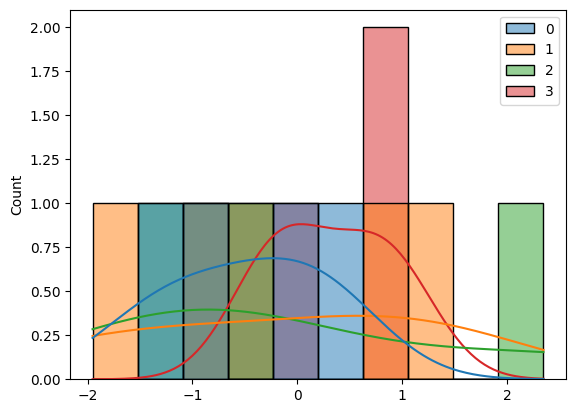

In [242]:
# Create a random number generator instance with an optional seed
rng = np.random.default_rng(seed = 12345)

# Generate a 4x4 array of samples from the standard normal distribution
data = rng.standard_normal((4,4))
print(data)

import seaborn as sns 
sns.histplot(data , bins =10 ,kde =True)



Common Random Functions:

rng.standard_normal(size): Draws samples from a standard Normal distribution (mean 0, variance 1).

rng.integers(low, high, size): Draws random integers from a given low-to-high range.

rng.uniform(size): Draws samples from a uniform [0, 1) distribution.

In [238]:
#  rng.integers(low, high, size) -> Draws random integers from a given low-to-high range.


rng = np.random.default_rng(12345)

x = rng.integers(1, 10, size=5)
print(x)

[7 3 8 3 2]


In [239]:
# rng.uniform(size): Draws samples from a uniform [0, 1) distribution.


rng = np.random.default_rng(12345)

x = rng.uniform(size=5)
print(x)

[0.22733602 0.31675834 0.79736546 0.67625467 0.39110955]


2. A Practical Example: Random Walks

Let's use NumPy operations to simulate a random walk. Imagine starting at 0, and taking 1,000 steps where each step is randomly either 1 or -1 with equal probability.

The Pure Python Way (Slow)

In pure Python, you would have to use a for loop to build this:

In [244]:
import random
position = 0
walk = [position]
for _ in range(1000):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)
print(step)
print(position)
print(walk)

-1
-16
[0, -1, -2, -3, -2, -3, -2, -1, 0, -1, -2, -3, -4, -3, -4, -3, -2, -3, -4, -5, -4, -3, -2, -3, -2, -1, -2, -3, -2, -1, -2, -3, -2, -3, -2, -3, -2, -3, -4, -3, -4, -3, -4, -5, -4, -3, -4, -5, -4, -3, -4, -5, -4, -5, -4, -3, -4, -5, -6, -5, -6, -7, -6, -7, -6, -5, -4, -3, -4, -3, -2, -1, 0, -1, 0, -1, -2, -1, 0, -1, 0, 1, 0, 1, 0, -1, 0, -1, -2, -1, 0, -1, 0, 1, 0, 1, 0, 1, 0, -1, 0, 1, 0, 1, 2, 3, 4, 5, 4, 3, 2, 3, 4, 3, 2, 1, 0, 1, 2, 1, 2, 3, 2, 3, 4, 5, 6, 7, 8, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 5, 6, 7, 6, 5, 4, 3, 2, 3, 2, 3, 2, 1, 2, 3, 2, 1, 0, -1, 0, -1, 0, -1, 0, 1, 0, 1, 2, 1, 2, 3, 4, 3, 4, 3, 4, 3, 4, 5, 6, 7, 6, 7, 6, 5, 6, 5, 4, 5, 6, 5, 4, 5, 4, 5, 6, 5, 4, 3, 4, 3, 4, 5, 6, 5, 6, 5, 4, 5, 6, 5, 4, 3, 2, 3, 4, 3, 4, 5, 6, 7, 6, 7, 8, 9, 10, 11, 10, 9, 8, 7, 8, 7, 6, 5, 4, 3, 4, 5, 6, 5, 6, 5, 6, 7, 6, 5, 6, 7, 8, 7, 6, 7, 8, 7, 6, 7, 8, 9, 10, 9, 8, 9, 10, 9, 8, 7, 8, 7, 8, 9, 10, 11, 12, 13, 12, 11, 10, 11, 12, 13, 14, 15, 14, 15, 14, 13, 12, 13, 14, 15, 14, 13,

The NumPy Way (Fast & Vectorized)

We can use the numpy.random module to draw 1,000 coin flips at once, use np.where to convert them to steps, and use .cumsum() to calculate the cumulative sum (the walk)!

In [247]:
# 1. Generate 1000 random 0s and 1s
draws = rng.integers(0 ,2 ,size =1000)

# 2. Convert 0s to -1, and 1s to 1
steps = np.where(draws==0 , -1 , 1)

# 3. Calculate the cumulative sum to get the exact position at each step
walk = steps.cumsum()
print(step)
print(position)
print(walk)


-1
-16
[  1   0   1   0  -1  -2  -3  -2  -3  -4  -5  -6  -5  -4  -5  -4  -3  -4
  -3  -2  -3  -4  -5  -6  -7  -6  -5  -6  -5  -6  -5  -6  -7  -8  -9 -10
  -9 -10 -11 -12 -13 -14 -15 -14 -13 -12 -13 -12 -11 -10 -11 -10 -11 -12
 -11 -12 -13 -14 -13 -12 -13 -12 -13 -12 -11 -10 -11 -12 -11 -12 -13 -12
 -13 -12 -11 -12 -11 -10  -9 -10 -11 -12 -11 -10  -9  -8  -7  -8  -7  -8
  -9  -8  -9 -10 -11 -10  -9  -8  -9  -8  -9 -10 -11 -10  -9 -10 -11 -12
 -11 -10 -11 -12 -11 -12 -13 -12 -11 -12 -11 -12 -11 -10 -11 -12 -13 -14
 -13 -14 -15 -16 -17 -16 -15 -14 -15 -14 -13 -14 -13 -14 -15 -14 -13 -14
 -15 -16 -15 -14 -15 -16 -17 -18 -17 -16 -15 -14 -13 -14 -15 -16 -17 -18
 -19 -20 -21 -22 -23 -24 -25 -26 -25 -26 -25 -24 -25 -24 -23 -22 -21 -22
 -21 -20 -19 -20 -19 -20 -21 -22 -23 -22 -21 -22 -23 -22 -23 -22 -23 -22
 -21 -20 -19 -18 -19 -18 -19 -20 -21 -22 -23 -24 -23 -24 -23 -24 -25 -26
 -27 -28 -29 -30 -31 -30 -31 -32 -31 -30 -31 -32 -33 -32 -33 -34 -33 -34
 -35 -36 -35 -34 -35 -36 -35 -36 -37 -36 -37

Now that we have our walk array, we can easily extract statistics using the methods we learned in Lecture 4!

In [ ]:
# What was the furthest we wandered in the negative direction?
print(walk.min())

# What was the furthest we wandered in the positive direction?
print(walk.max())

# At what exact step did we first reach 10 steps away from the origin?
# (np.abs() is a ufunc that takes the absolute value!)
first_crossing = (np.abs(walk) >= 10).argmax()
print(first_crossing)


-69
1
35


np.int64(-10)